In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
rng = np.random.default_rng(seed=42) #the noise
print("Ready.")

Ready.


In [28]:
z = np.linspace(0.001, 5.0, 1000)

print(f"Redshift range: {z[0]:.3f} to {z[-1]:.1f}")
print(f"Number of points: {len(z)}")

Redshift range: 0.001 to 5.0
Number of points: 1000


What this is: Your x-axis. Redshift from nearly zero (nearby galaxies) to z=2 (light that left 10 billion years ago). 1000 points across that range.

In [29]:
# Cosmological parameters (Planck 2018 values)
H0 = 70.0          # km/s/Mpc today
Omega_m = 0.3      # matter density fraction
Omega_L = 0.7      # dark energy density fraction

def E(z):
    """Dimensionless Hubble parameter at redshift z.
    This is the rate of expansion at each step of the journey.
    H(z) = H0 * E(z)
    """
    return np.sqrt(Omega_m * (1 + z)**3 + Omega_L)

print(f"E(0) today: {E(0):.3f}")
print(f"E(1) at z=1: {E(1):.3f}")
print(f"E(2) at z=2: {E(2):.3f}")

E(0) today: 1.000
E(1) at z=1: 1.761
E(2) at z=2: 2.966


$E(z)$ is how the expansion rate changed over cosmic history. At
$z = 0$ it's $1$ — today. At higher $z$ it's larger — the universe was expanding faster in the past due to matter domination. This is what makes each $\delta_i$​ different.

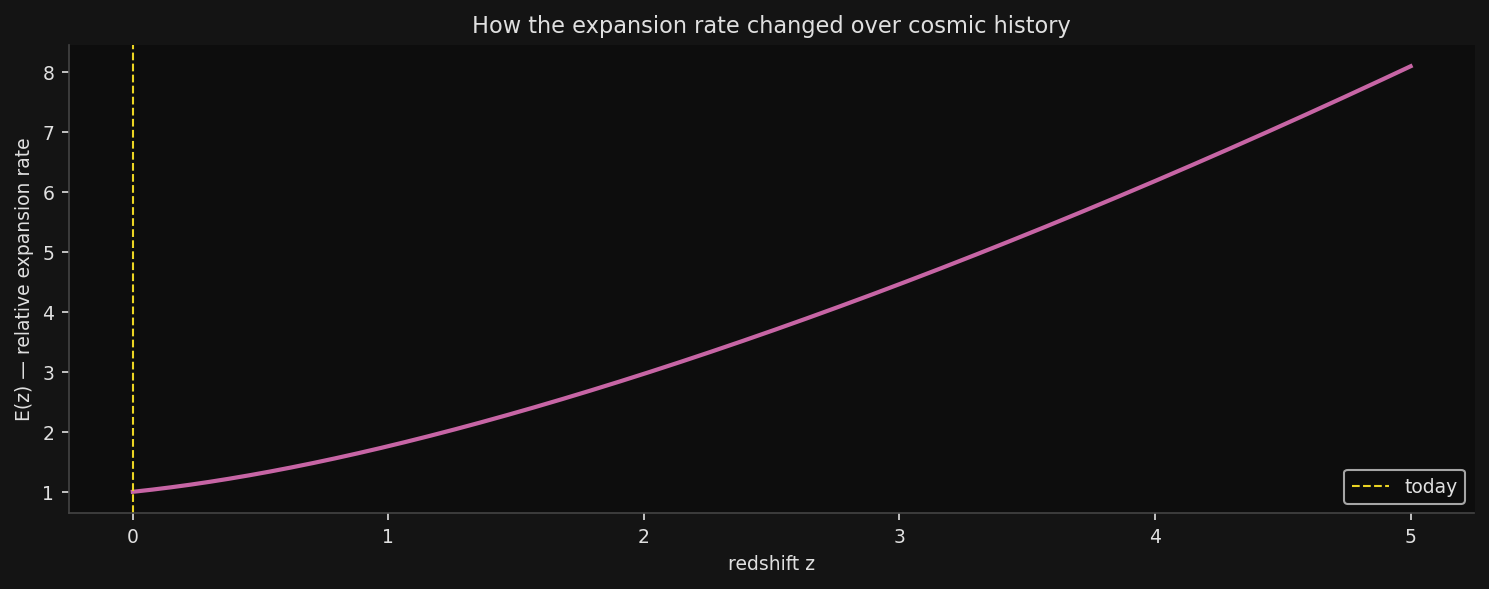

In [30]:
plt.figure(figsize=(10, 4))
plt.plot(z, E(z), color="#c765a5", linewidth=2)
plt.xlabel('redshift z')
plt.ylabel('E(z) — relative expansion rate')
plt.title('How the expansion rate changed over cosmic history')
plt.axvline(0,color = "#ebd423", linestyle='--', linewidth=1, label='today')
plt.legend()
plt.tight_layout()
plt.show()

What this is: You're looking at $\delta_i$ as a function of when in cosmic history. Higher $E(z)$
at high $z$ means expansion was faster then — each $\delta_i$ ​ was larger. This is the function that goes inside your integral.

In [31]:
c = 3e5  # speed of light in km/s

def distance_yours(z):
    """Your formula: d = delta x n, assuming constant stretch rate."""
    return (c / H0) * z

d_yours = distance_yours(z)

print(f"Your formula at z=0.004 (NGC 7619): {distance_yours(0.004):.1f} Mpc")
print(f"Your formula at z=1.0: {distance_yours(1.0):.1f} Mpc")
print(f"Your formula at z=2.0: {distance_yours(2.0):.1f} Mpc")

Your formula at z=0.004 (NGC 7619): 17.1 Mpc
Your formula at z=1.0: 4285.7 Mpc
Your formula at z=2.0: 8571.4 Mpc


**What this is:** Your $d = \delta \times n$ with constant $\delta$. Clean, linear, exact for small $z$. This is the first order approximation — every $\delta_i$ assumed equal to today's value.

In [32]:
def distance_integral(z_val):
    """Honest formula: sum all delta_i's over the journey.
    Each delta_i weighted by E(z) at that moment in history.
    """
    integral, _ = quad(lambda zp: 1.0 / E(zp), 0, z_val)
    return (c / H0) * integral

# Compute over all redshifts
d_integral = np.array([distance_integral(zi) for zi in z])

print(f"Integral at z=0.004 (NGC 7619): {distance_integral(0.004):.1f} Mpc")
print(f"Integral at z=1.0: {distance_integral(1.0):.1f} Mpc")
print(f"Integral at z=2.0: {distance_integral(2.0):.1f} Mpc")

Integral at z=0.004 (NGC 7619): 17.1 Mpc
Integral at z=1.0: 3306.1 Mpc
Integral at z=2.0: 5183.4 Mpc


**What this is:**$\sum_i \delta_i$ done properly. At each step of the journey, $\delta_i$ is weighted by $1/E(z)$ — the actual expansion rate at that moment. quad() sums up all those tiny slices numerically.

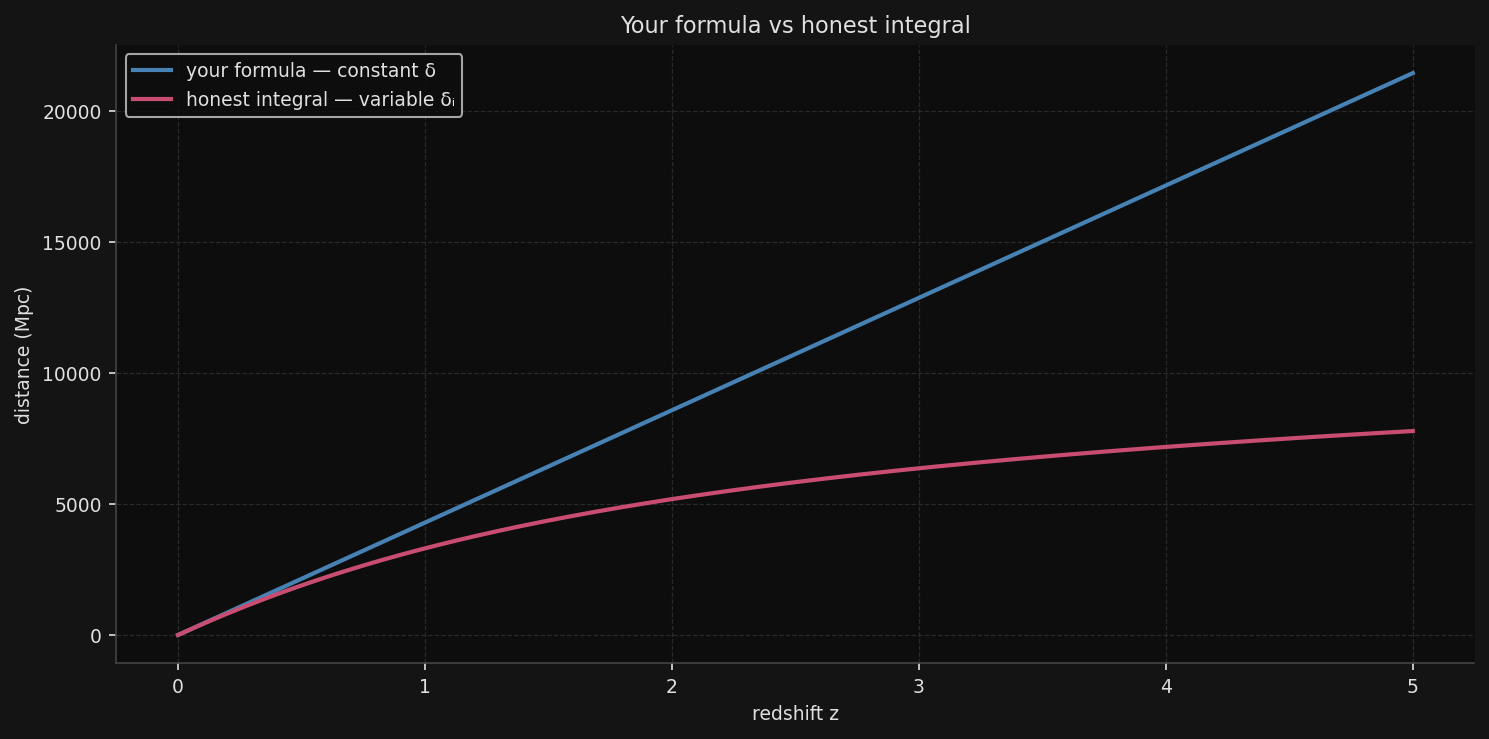

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(z, d_yours, color='steelblue', linewidth=2, 
         label='your formula — constant δ')
plt.plot(z, d_integral, color="#c94d70", linewidth=2, 
         label='honest integral — variable δᵢ')
plt.xlabel('redshift z')
plt.ylabel('distance (Mpc)')

plt.title('Your formula vs honest integral')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

**What this is:** The two formulas plotted together. At low $z$ they should be nearly identical — NGC 7619 territory. At high $z$ they diverge. The gap between the lines is the accumulated error from assuming constant $\delta$.

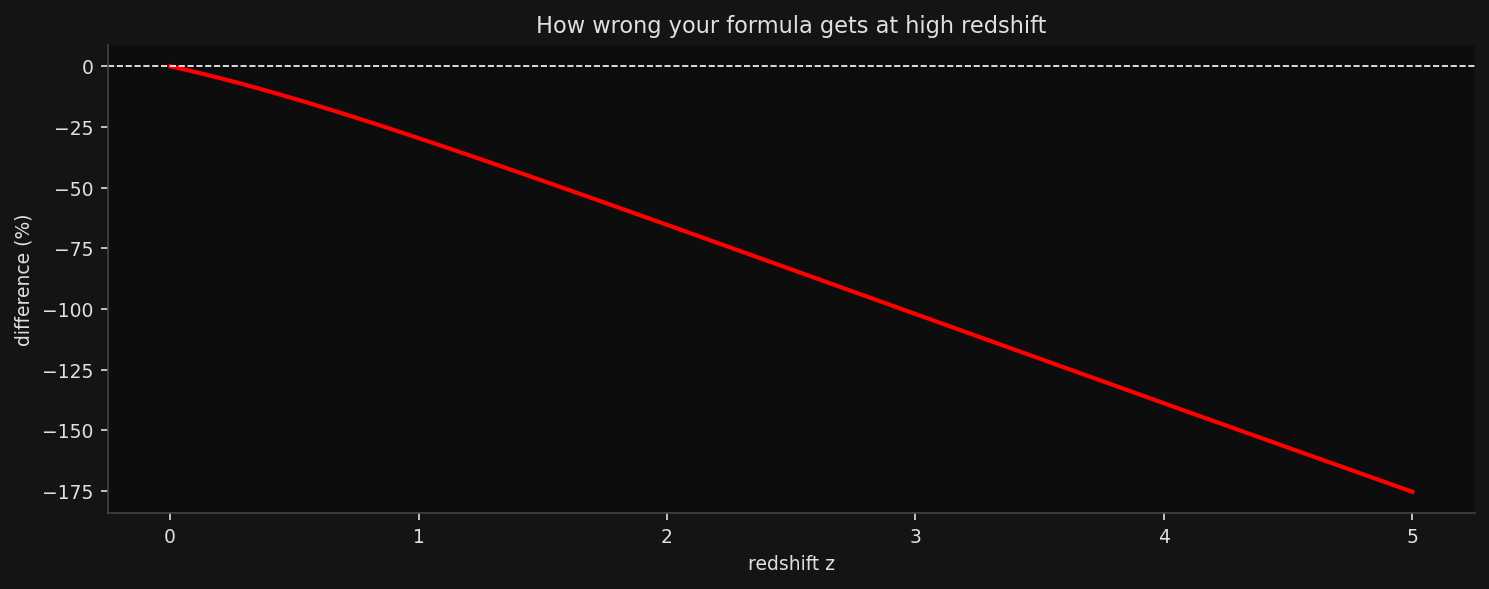

Difference at z=0.004: -0.090%
Difference at z=1.0:   -29.6%
Difference at z=2.0:   -65.4%


In [34]:
diff = 100 * (d_integral - d_yours) / d_integral

plt.figure(figsize=(10, 4))
plt.plot(z, diff, color='red', linewidth=2)
plt.xlabel('redshift z')
plt.ylabel('difference (%)')
plt.title('How wrong your formula gets at high redshift')
plt.axhline(0, color='white', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

print(f"Difference at z=0.004: {np.interp(0.004, z, diff):.3f}%")
print(f"Difference at z=1.0:   {np.interp(1.0, z, diff):.1f}%")
print(f"Difference at z=2.0:   {np.interp(2.0, z, diff):.1f}%")


**What this is:** The error in your formula as a function of redshift. Near zero for nearby galaxies. Grows as you look further back in time — because the further back you look, the more cosmic history you're averaging over, and the more the expansion rate changed.

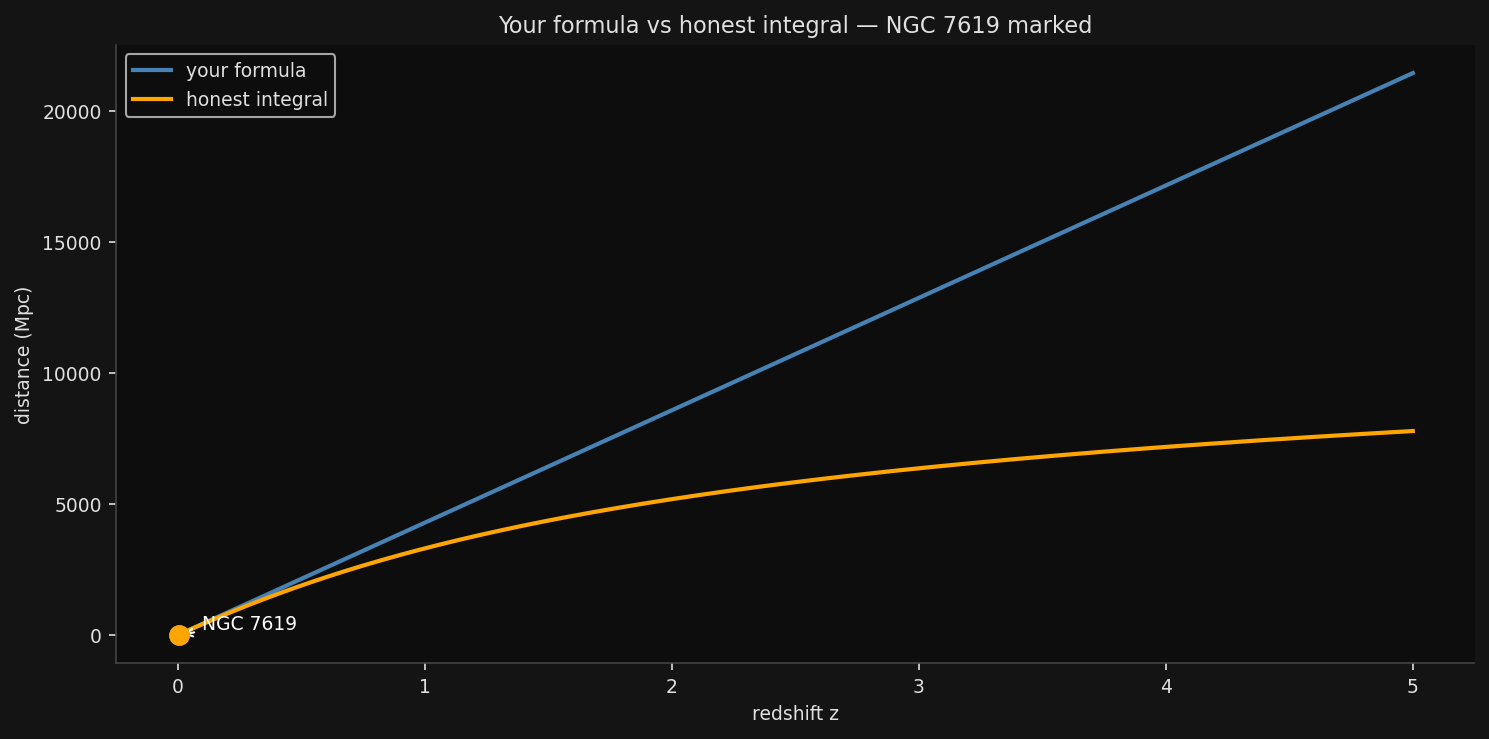

NGC 7619 — your formula: 17.0 Mpc
NGC 7619 — integral:     17.0 Mpc


In [35]:
z_ngc = 0.00396
d_ngc_yours = distance_yours(z_ngc)
d_ngc_integral = distance_integral(z_ngc)

plt.figure(figsize=(10, 5))
plt.plot(z, d_yours, color='steelblue', linewidth=2, label='your formula')
plt.plot(z, d_integral, color='orange', linewidth=2, label='honest integral')
plt.scatter([z_ngc], [d_ngc_yours], color='steelblue', s=80, zorder=5)
plt.scatter([z_ngc], [d_ngc_integral], color='orange', s=80, zorder=5)
plt.annotate('NGC 7619', xy=(z_ngc, d_ngc_integral), 
             xytext=(0.1, 200), color='white',
             arrowprops=dict(arrowstyle='->', color='white'))
plt.xlabel('redshift z')
plt.ylabel('distance (Mpc)')
plt.title('Your formula vs honest integral — NGC 7619 marked')
plt.legend()
plt.tight_layout()
plt.show()

print(f"NGC 7619 — your formula: {d_ngc_yours:.1f} Mpc")
print(f"NGC 7619 — integral:     {d_ngc_integral:.1f} Mpc")

**What this is:** Putting the real galaxy we calculated by hand back onto the plot. At $z = 0.004$ the two formulas are essentially identical — exactly as predicted.